In [2]:
import pandas as pd


df = pd.read_csv('Walmart.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


(6435, 8)

In [4]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [5]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [6]:
df['Date'].head()

,Date
0,2010-02-05
1,2010-02-12
2,2010-02-19
3,2010-02-26
4,2010-03-05


In [33]:
from numpy._core.defchararray import replace
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False, if_exists='replace')


6435

In [25]:
query1 = """
SELECT Store, ROUND(SUM(Weekly_Sales),2) AS Total_sales
From sales
GROUP BY Store
ORDER BY total_sales DESC
LIMIT 20"""
top_stores = pd.read_sql(query1,conn)
top_stores

,Store,Total_sales
0,20,3.013978e+08
1,4,2.995440e+08
2,14,2.889999e+08
3,13,2.865177e+08
4,2,2.753824e+08
5,10,2.716177e+08
6,27,2.538559e+08
7,6,2.237561e+08
8,1,2.224028e+08
9,39,2.074455e+08


In [15]:
query2 = """
SELECT
  CASE
    WHEN Holiday_Flag = 1 THEN 'Праздничный день'
    ELSE 'Обычный день'
  END AS Type_day,
  ROUND(AVG(Weekly_sales), 2) AS AVG_sales,
  COUNT(*) AS Weekend_count
FROM sales
GROUP BY Holiday_Flag
"""

holiday_count = pd.read_sql(query2,conn)
holiday_count

,Type_day,AVG_sales,Weekend_count
0,Обычный день,1041256.38,5985
1,Праздничный день,1122887.89,450


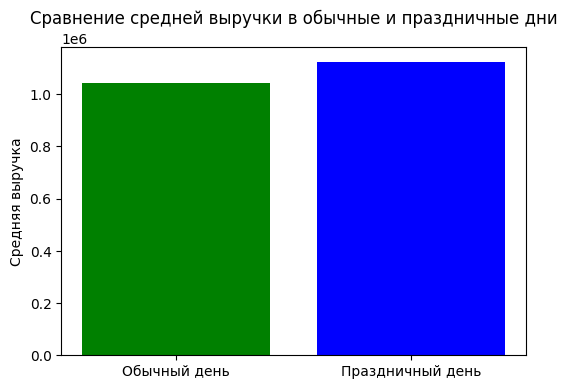

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(holiday_count['Type_day'], holiday_count['AVG_sales'], color = ['Green', 'Blue'])
plt.title('Сравнение средней выручки в обычные и праздничные дни')
plt.ylabel('Средняя выручка')
plt.show()


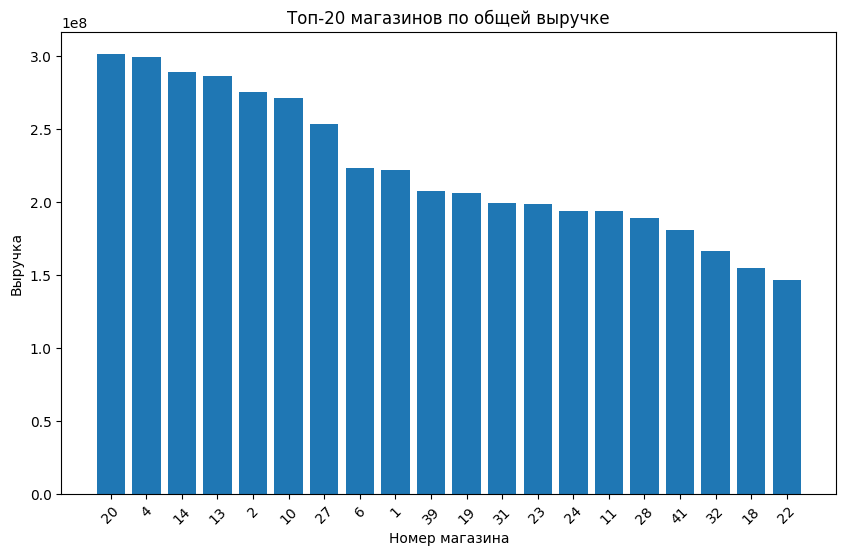

In [32]:
plt.figure(figsize=(10,6))
plt.bar(top_stores['Store'].astype(str), top_stores['Total_sales'])
plt.title('Топ-20 магазинов по общей выручке')
plt.xlabel('Номер магазина')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.show()

In [41]:
query3 = """
SELECT
  strftime('%Y-%m', Date) AS Month,
  ROUND(SUM(Weekly_Sales),2) AS Total_sales
FROM sales
GROUP BY Month
ORDER BY Month
"""

monthly_sales = pd.read_sql(query3, conn)
monthly_sales

,Month,Total_sales
0,2010-02,1.903330e+08
1,2010-03,1.819198e+08
2,2010-04,2.314124e+08
3,2010-05,1.867109e+08
4,2010-06,1.922462e+08
5,2010-07,2.325801e+08
6,2010-08,1.876401e+08
7,2010-09,1.772679e+08
8,2010-10,2.171618e+08
9,2010-11,2.028534e+08


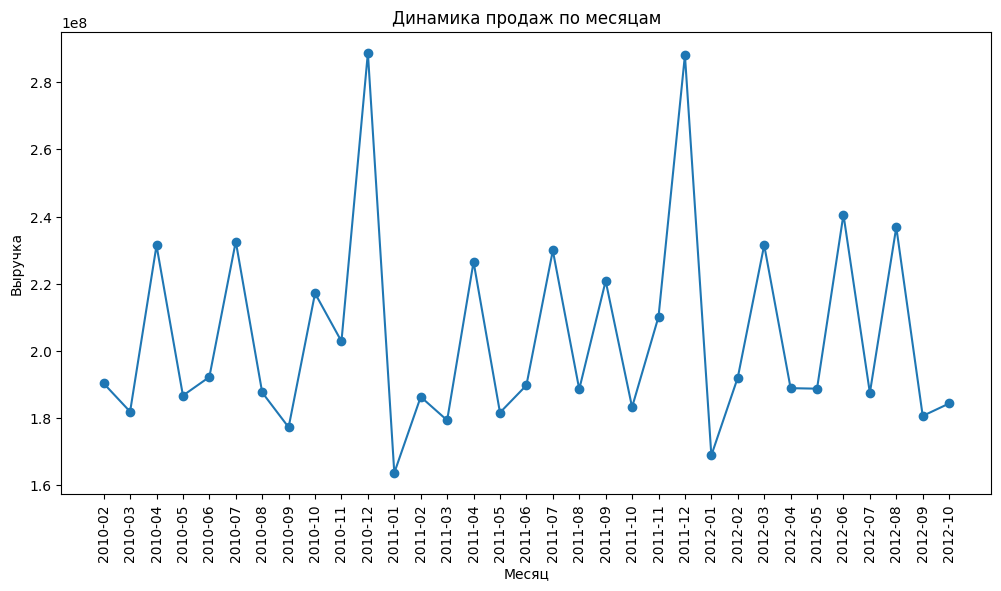

In [45]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Month'], monthly_sales['Total_sales'], marker = 'o')
plt.title('Динамика продаж по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.xticks(rotation=90)
plt.show()